Dimensiones en milímetros

<img src = "images/example2_1.PNG" width = "500">

<img src = "images/example2_2.PNG" width = "300">

In [1]:
import numpy as np
import weld_calc as wc

In [2]:
alto = 56. / 1000.
ancho = 190. / 1000.
h = 6. / 1000.

# crear el primer cordón
bc = wc.Weld()   # c1 es un objeto de la clase Weld
bc.h = h         # es el tamaño del cordón
# los cordones siempre deben estar en las dos primeras coordenadas
bc.start_point = np.array([0., 0., 0.])
bc.end_point = np.array([0., alto, 0.])
bc.weld_calcs()   # se calcula internamente variables del cordón
                  # es un método de la clase Weld()
bc.print_report() # método de la clase Weld() muestra un reporte de variables internas
bc.color = "black"
bc.name = "BC"

############
--- REPORT ---
############
Name  = Weld 1
l     = 0.056000 m
Area  = 0.000238 m²
JG    = 0.000000 m⁴
Ixx_loc = 0.000000 m⁴
Iyy_loc = 0.000000 m⁴
Ixy_loc = 0.000000 m⁴
Centroid:
xG    = 0.000000 m
yG    = 0.028000 m
Angle = 90.00°


In [3]:
cd = wc.Weld()
cd.h = h
cd.start_point = np.array([0., alto, 0.])
cd.end_point = np.array([ancho, alto, 0.])
cd.weld_calcs()
cd.color = "blue"
cd.name = "CD"
cd.print_report()

############
--- REPORT ---
############
Name  = CD
l     = 0.190000 m
Area  = 0.000806 m²
JG    = 0.000002 m⁴
Ixx_loc = 0.000000 m⁴
Iyy_loc = 0.000002 m⁴
Ixy_loc = 0.000000 m⁴
Centroid:
xG    = 0.095000 m
yG    = 0.056000 m
Angle = 0.00°


In [4]:
da = wc.Weld()
da.h = h
da.start_point = np.array([ancho, alto, 0.])
da.end_point = np.array([ancho, 0., 0.])
da.weld_calcs()
da.color = "green"
da.name = "DA"
da.print_report()

############
--- REPORT ---
############
Name  = DA
l     = 0.056000 m
Area  = 0.000238 m²
JG    = 0.000000 m⁴
Ixx_loc = 0.000000 m⁴
Iyy_loc = 0.000000 m⁴
Ixy_loc = -0.000000 m⁴
Centroid:
xG    = 0.190000 m
yG    = 0.028000 m
Angle = -90.00°


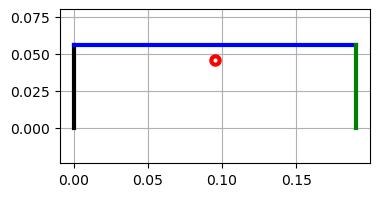

In [5]:
wj = wc.Weld_joint()   # se crea un objeto llamado wj de la clase Weld_joint()
wj.welds = [bc, cd, da]    # se guardan en una lista los cordones definidos  
wj.weld_calcs()        # cálculos internos de la unión soldada
wj.figure_size = (4, 2)     # tupla con tamaño de imagen (pulgadas)
wj.plot_welds()

In [6]:
n_points1 = 9
n_points2 = 15
eq1 = wc.equidistant_points(bc, n_points1)
eq2 = wc.equidistant_points(cd, n_points2)
eq3 = wc.equidistant_points(da, n_points1)

weld_points = np.vstack((eq1, eq2, eq3))
weld_points = wc.remove_repeats(weld_points)

In [7]:
pos = (56. + 100.) / 1000.
F = np.array([25000., 0., 0.])
point = np.array([ancho * 0.5, pos, 0.])

forces = [F]
points = [point]

wj.weld_evaluation(forces, points, weld_points)

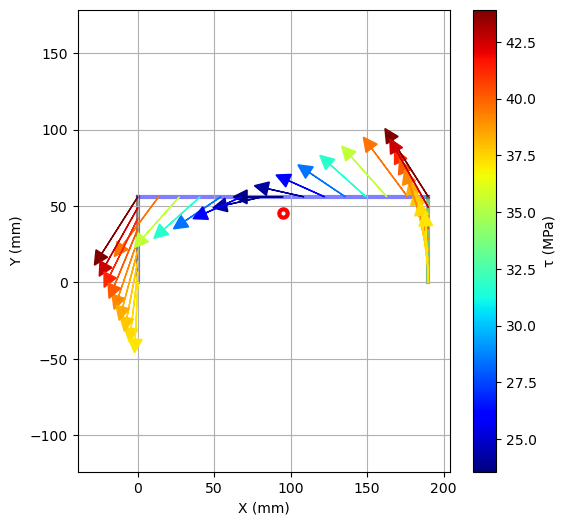

In [8]:
wj.figure_size = (6, 6)    # tamaño de figura (9 x 6) pulgadas
# Si se desea ver también las componentes por separado, se puede llamar de nuevo:
wj.plot_vectors(
    weld_points,
    plot_type='tau',
    scale_vectors=3,
    scale_magnitud=1e-6,
    scale_points=1000,
    plot_TAU_1=False,           # muestra TAU_1 con línea discontinua gris
    plot_TAU_2=False,           # muestra TAU_2 con línea punteada gris
    show_weld_lines=True
)

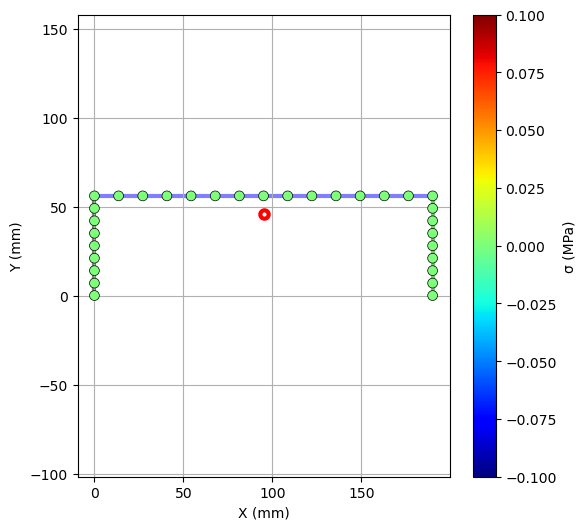

In [9]:
# Tensiones normales
wj.plot_vectors(weld_points, plot_type = 'sigma', save_figure=True)
wj.figure_name = "tensiones_normales.png"

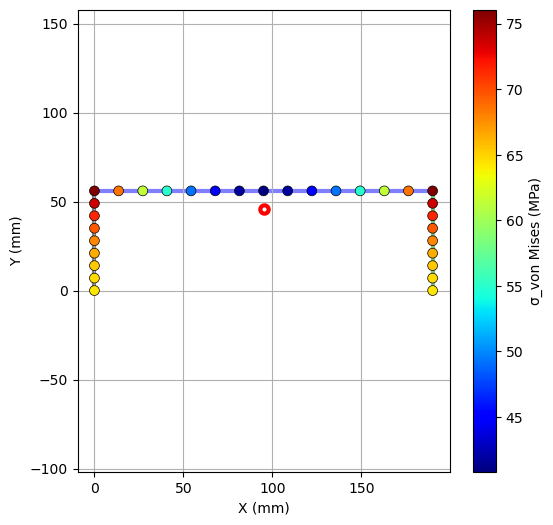

In [10]:
# Tensión de von Mises
wj.plot_vectors(weld_points, plot_type = 'von_mises', save_figure=True)
wj.figure_name = "von_mises.png"

In [12]:
# 1. Factor de seguridad
fluencia = 250e6  # 250 MPa
n_min, n_list = wj.safety_factor(yield_strength = fluencia, criterion = 'vm')
print(f"Factor de seguridad mínimo (von Mises): {n_min:.2f}")

Factor de seguridad mínimo (von Mises): 3.29


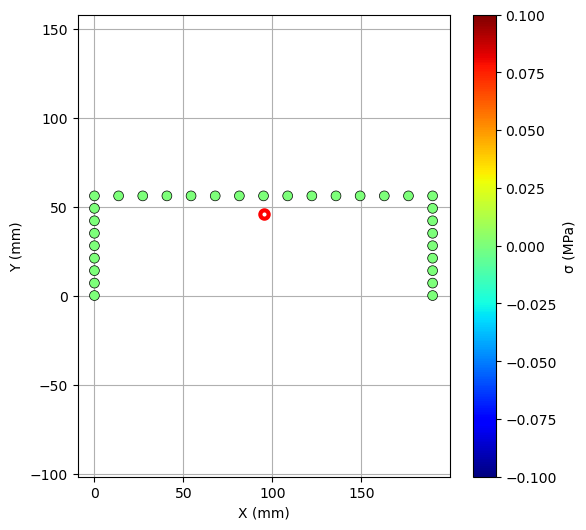

In [13]:
# 3. Plot de vectores sin líneas de cordones (solo puntos)
wj.plot_vectors(weld_points, plot_type='sigma', show_weld_lines=False)

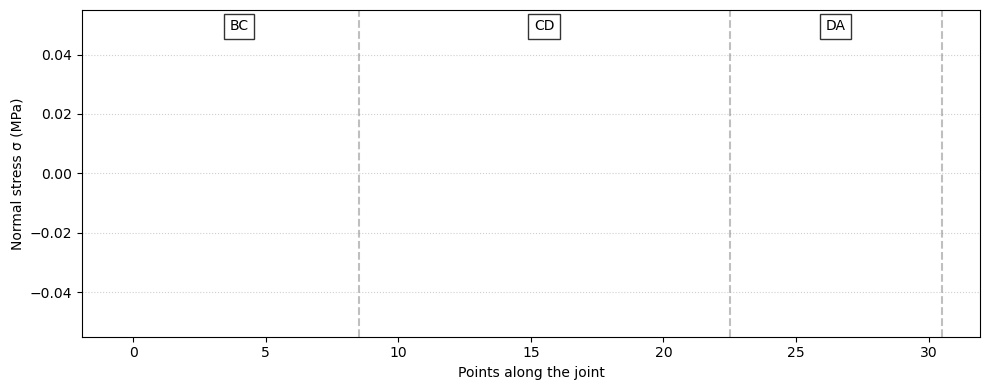

In [14]:
wj.plot_sigma_unfolded(weld_points)

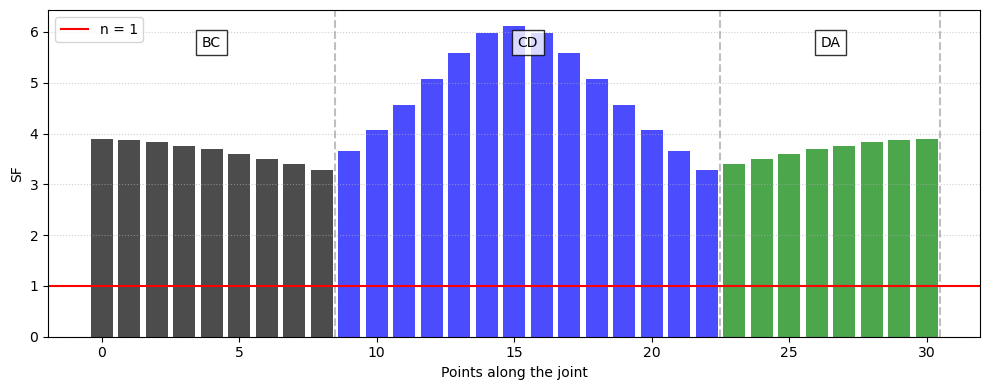

In [15]:
wj.plot_n_unfolded(weld_points, fluencia, criterion = 'vm')